In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('/content/cardio_data_cleaned(IQR).csv')
X = df.drop('cardio', axis=1)
y = df['cardio']
feature_names = X.columns.tolist()

X = X.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
feature_names

['age',
 'gender',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'BMI',
 'MAP']

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(
  n_estimators=50,
  max_depth=5,
  learning_rate=0.2,
  random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy of the test data : {accuracy:.4f}")
accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy of the train data : {accuracy:.4f}")


Accuracy of the test data : 0.7211
Accuracy of the train data : 0.7202


ROC

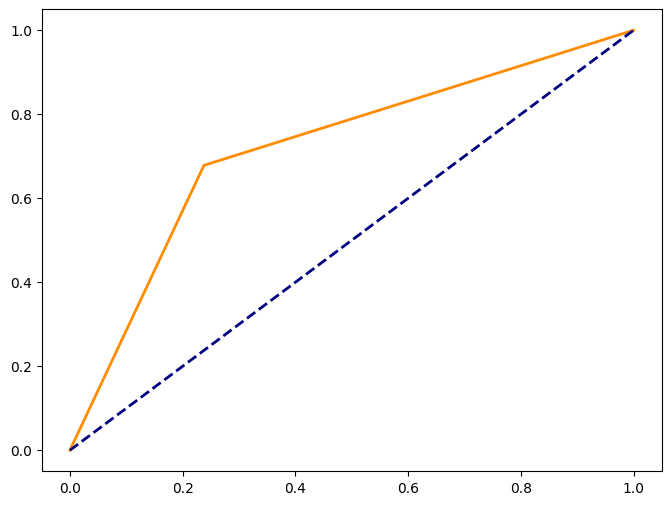

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

Shap

In [ ]:
pip install shap

In [ ]:
import shap
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(model)
explanation = explainer(X_test_df)

shap_values = explanation.values
np.abs(shap_values.sum(axis=1) + explanation.base_values - y_test_pred).max()

np.float64(3.37278413772583)

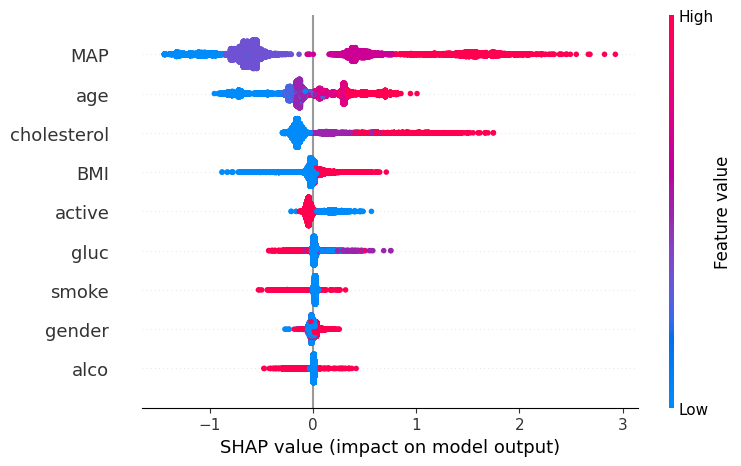

In [ ]:
shap.plots.beeswarm(explanation)


Shap dependence plot

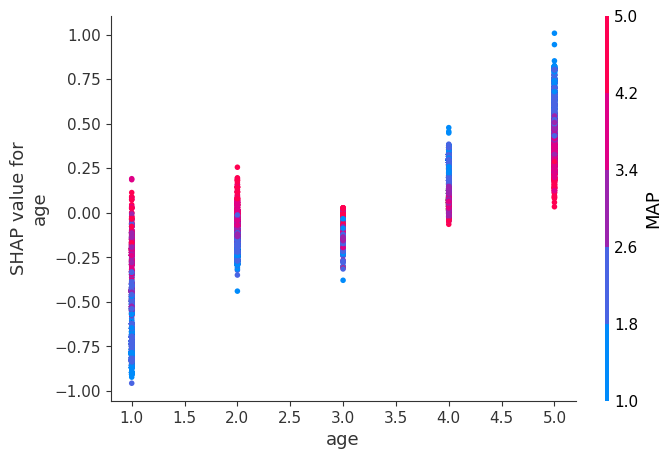

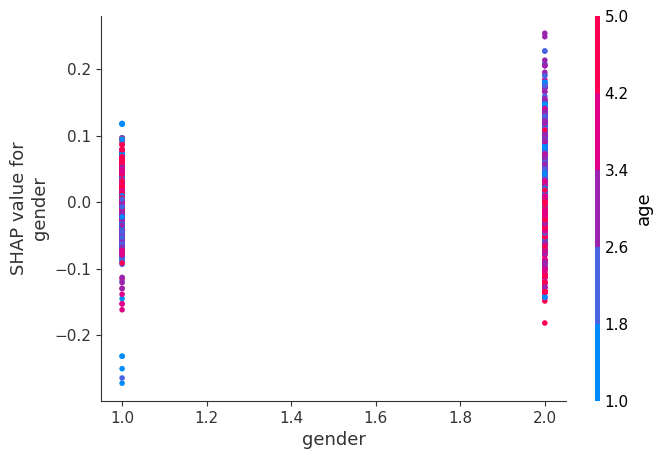

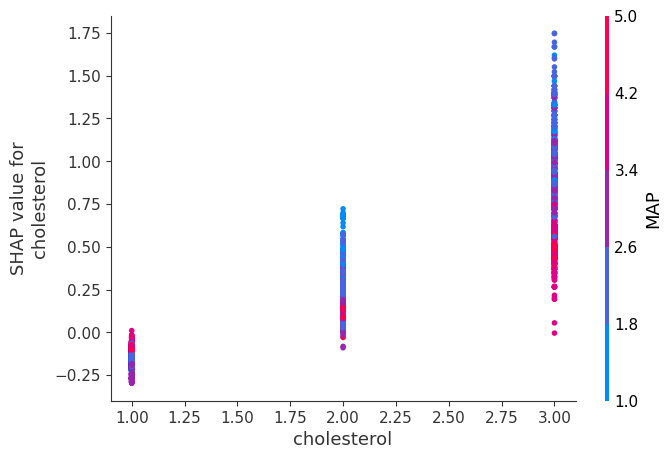

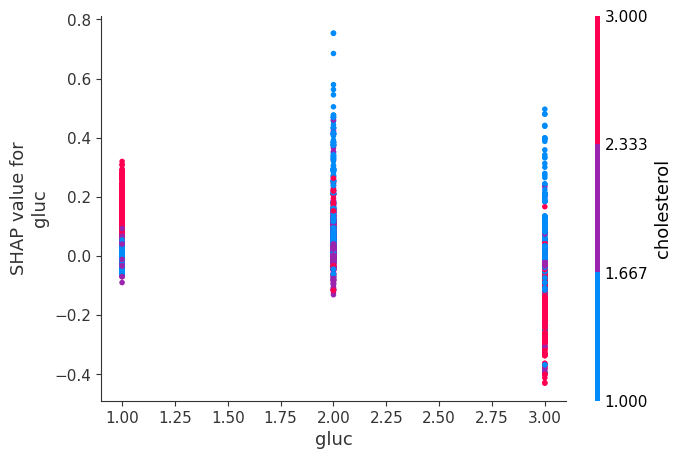

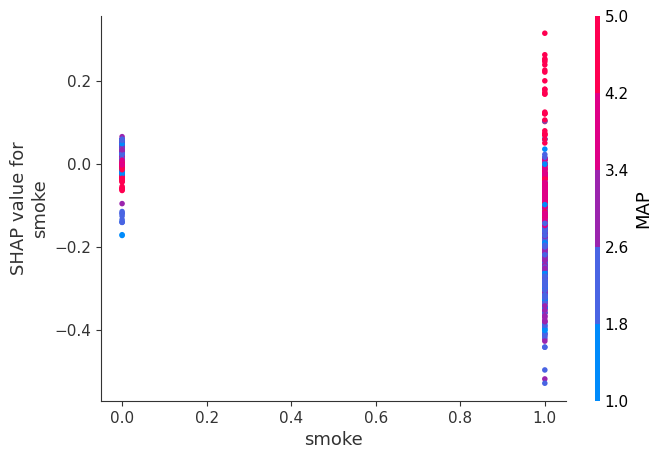

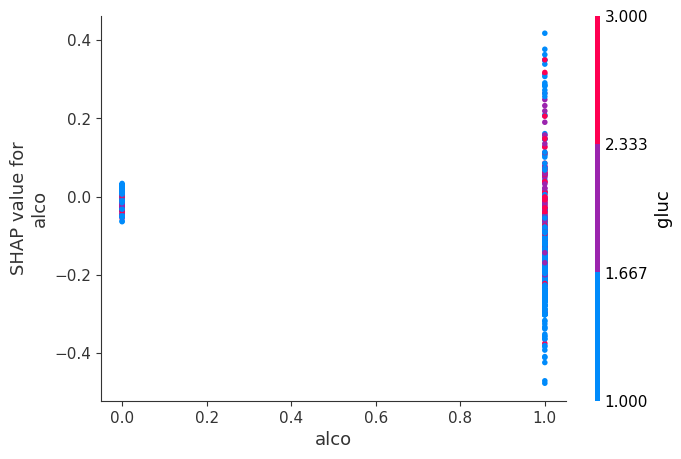

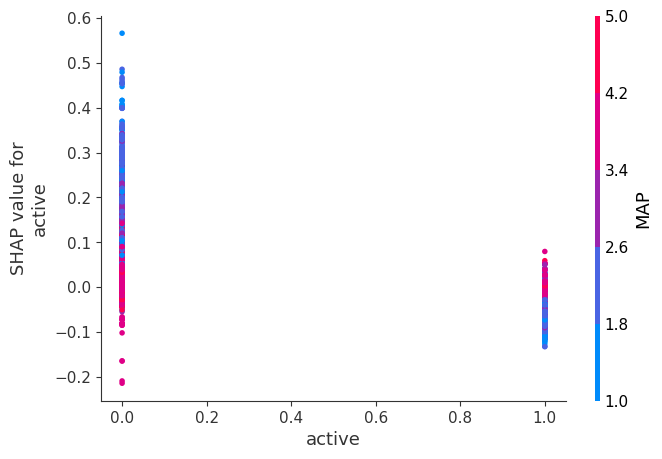

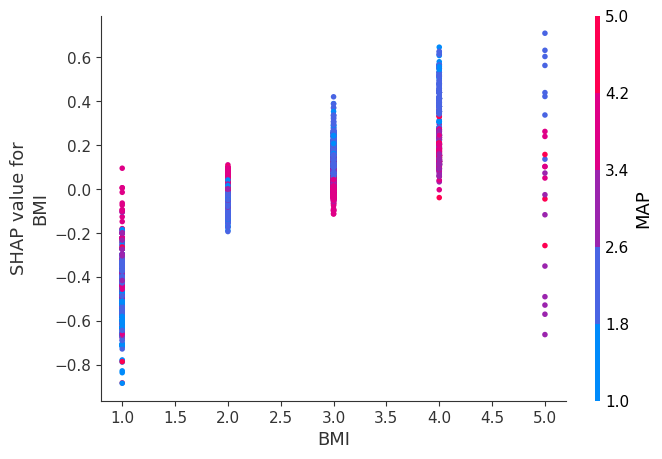

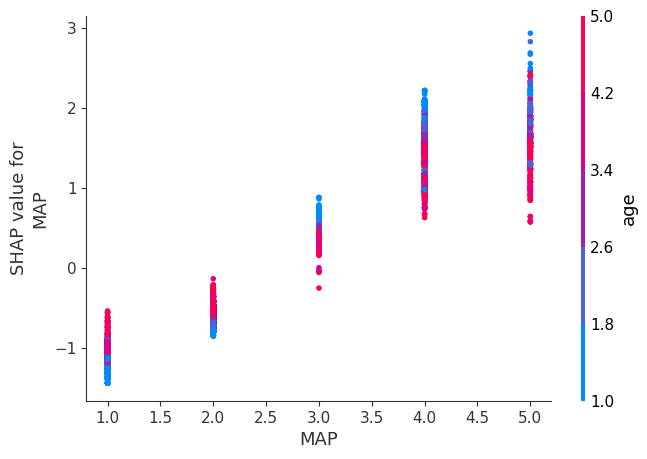

In [ ]:
for i in range(len(feature_names)):
  shap.dependence_plot(feature_names[i], explanation.values, X_test_df)


Waterfall plot

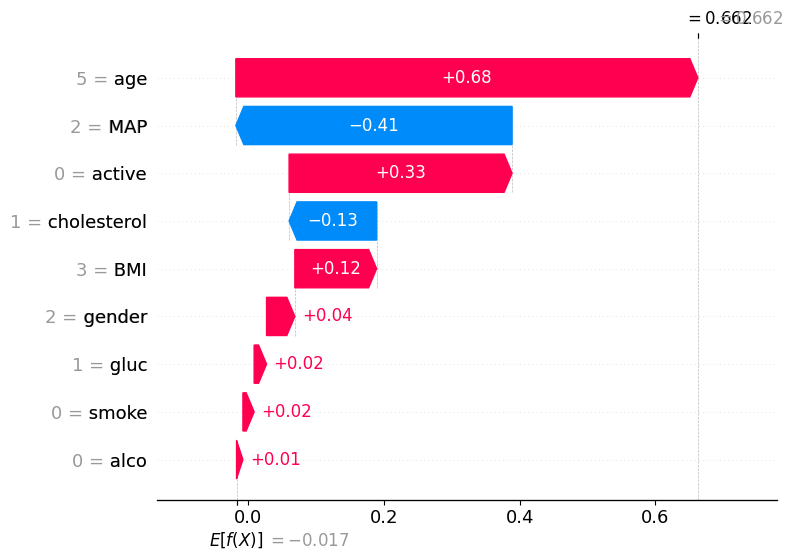

In [ ]:
shap.plots.waterfall(explanation[0])

Shapash

In [ ]:
pip install shapash

In [ ]:
from shapash.explainer.smart_explainer import SmartExplainer
import xgboost as xgb
import pandas as pd

xpl = SmartExplainer(model=model)


y_pred_series = pd.Series(model.predict(X_test_df), index=X_test_df.index)
xpl.compile(
    x= X_test_df,
    y_pred=y_pred_series
)

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x7a153b74f5d0>


In [ ]:
xpl.run_app()


Exception in thread 

<CustomThread(Thread-11 (<lambda>), started 134231485314624)>

Thread-11 (<lambda>):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner


In [ ]:
summary_df = xpl.to_pandas(max_contrib=2,proba=True)
summary_df.head()

,y_pred,proba,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2
0,1,0.659819,age,5.0,0.68094,MAP,2.0,-0.407139
1,0,0.619455,MAP,2.0,0.630545,cholesterol,2.0,-0.203129
2,0,0.911950,MAP,1.0,1.323418,age,1.0,0.785771
3,1,0.562044,MAP,3.0,0.476837,BMI,1.0,-0.271046
4,0,0.582555,MAP,2.0,0.470251,BMI,1.0,0.371316


Feature Importance using shapash

In [ ]:
xpl.plot.features_importance()

Explaning instance 0

In [ ]:
xpl.plot.local_plot(index=0)

In [ ]:
xpl.plot.top_interactions_plot()

In [ ]:
xpl.plot.compare_plot(row_num=[0, 1, 2,5])

Dalex

In [ ]:
pip install dalex -U

In [ ]:
import dalex as dx
explainer = dx.Explainer(model, X_test_df, y_test)
explanation = explainer.model_parts()
explanation.result
explanation.plot()

Preparation of a new explainer is initiated

  -> data              : 18751 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 18751 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x7a153b7e1f80> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0332, mean = 0.495, max = 0.982
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.949, mean = -0.00423, max = 0.951
  -> model_info        : package xgboost

A new explainer has been created!


PDP

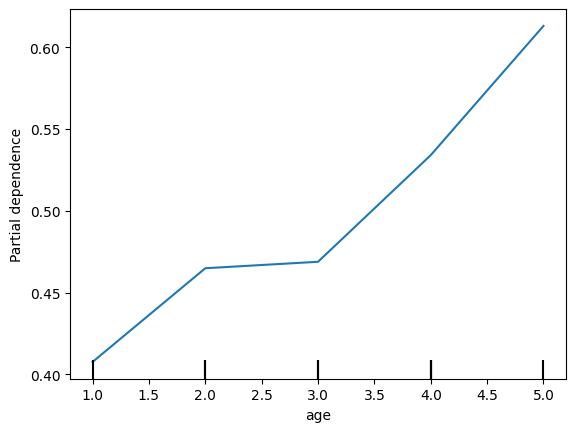

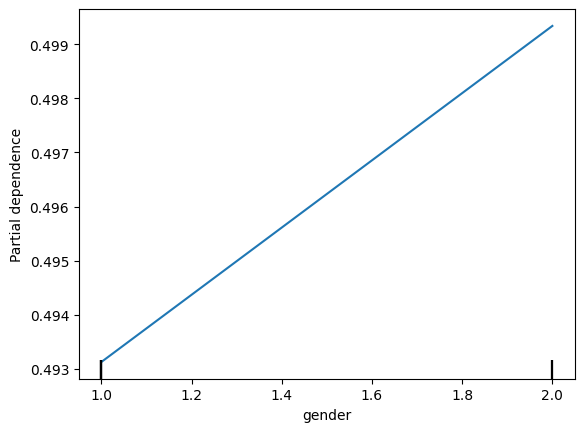

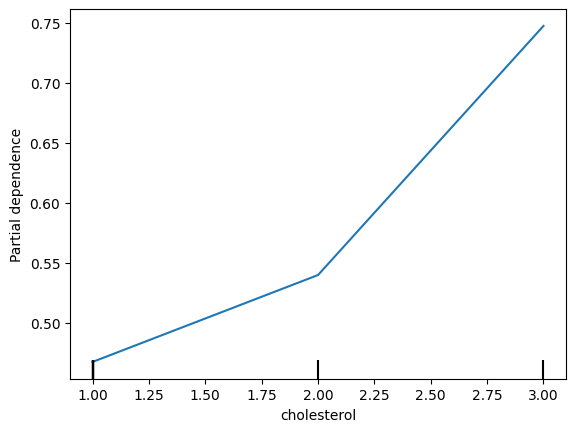

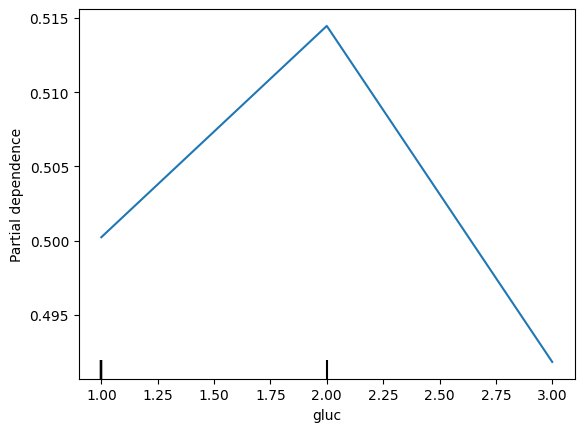

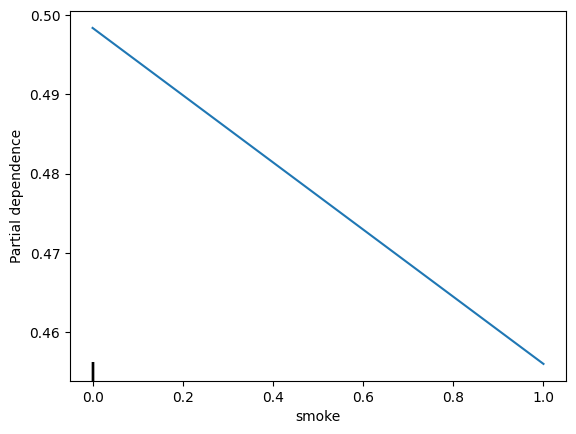

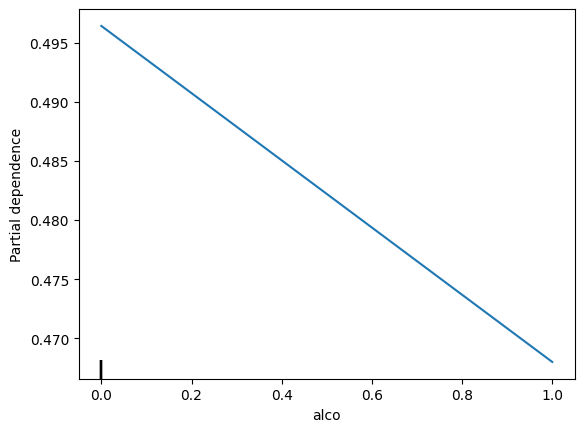

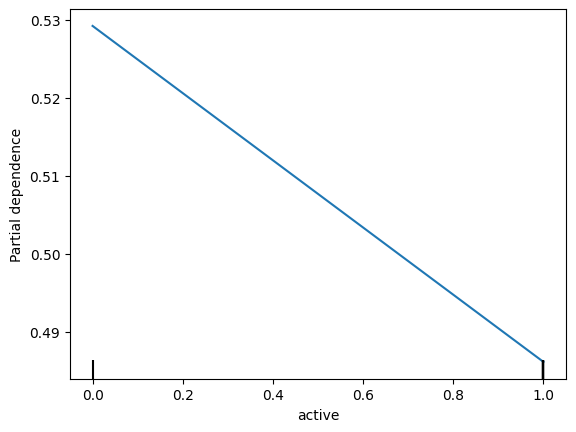

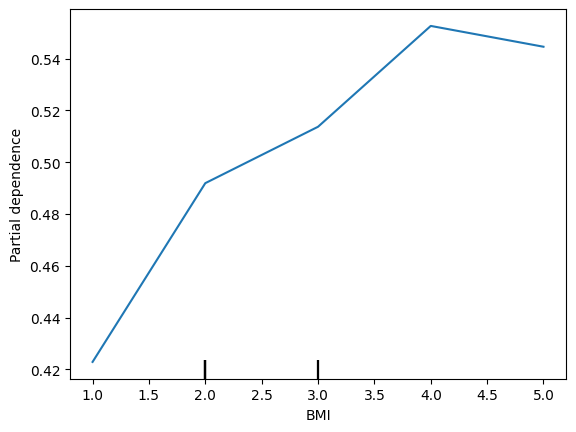

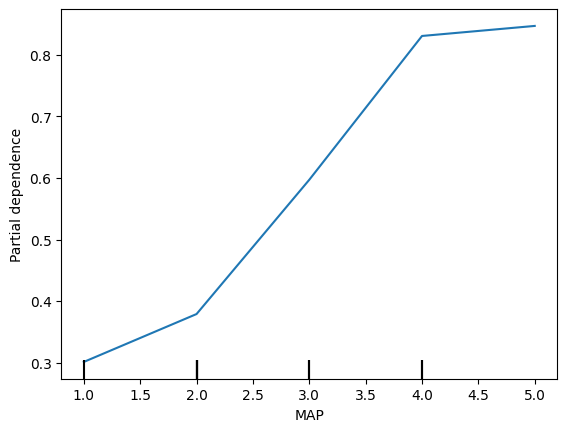

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
for i in range(len(feature_names)):
  PartialDependenceDisplay.from_estimator(model, X_test_df,features = [i])
